In [1]:
# --- 1) Setup: Project Root korrekt setzen + config laden ---
import sys
from pathlib import Path

# Notebook liegt in /notebooks -> Parent ist Projekt-Root
PROJECT_ROOT = Path.cwd().parent

# Projekt-Root in den Python-Pfad, damit "import config" funktioniert
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config
config.ensure_dirs()

print("KERNEL:", sys.executable)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_RAW:", config.DATA_RAW)
print("DATA_PROCESSED:", config.DATA_PROCESSED)
print("OUTPUTS_DIR:", config.OUTPUTS_DIR)


KERNEL: C:\Users\Noah\Anaconda\envs\pg3_royalty\python.exe
PROJECT_ROOT: C:\Users\Noah\PG3_Royalty_Python_Model
DATA_RAW: C:\Users\Noah\PG3_Royalty_Python_Model\Data\raw
DATA_PROCESSED: C:\Users\Noah\PG3_Royalty_Python_Model\Data\processed
OUTPUTS_DIR: C:\Users\Noah\PG3_Royalty_Python_Model\outputs


In [2]:
# --- 2) Clean GroundTruth Daten laden ---
import pandas as pd

df = pd.read_csv(config.GROUND_TRUTH_CSV)

print("Datei geladen:", config.GROUND_TRUTH_CSV)
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())


Datei geladen: C:\Users\Noah\PG3_Royalty_Python_Model\Data\processed\ground_truth_clean.csv
Rows: 16
Columns: 19


,Scenario,FY,Net_CF_to_Consortium,Op_Fee,Consortium_Fees,CF_after_Fees,Interest_Rate,Interest_Cost,Mandatory_Amort,Recap_DeltaDebt,Cash_Sweep,Debt_End,FCF_for_Distribution,NAV_Multiple,NAV,LTV,PG_Share,Equity_Ticket,Equity_CF
0,Base,2024,46.8,2.340,0.2,44.260,0.062,-20.15000,0.0,0.00,0.0,325.00,24.11000,14.0,655.20,0.496032,0.295394,99.4,-92.278056
1,Base,2025,50.3,2.515,0.0,47.785,0.056,-18.20000,0.0,0.00,0.0,325.00,29.58500,14.0,704.20,0.461517,0.295394,99.4,8.739224
2,Base,2026,53.7,2.685,0.0,51.015,0.057,-18.52500,0.0,126.08,0.0,451.08,32.49000,14.0,751.80,0.600000,0.295394,99.4,9.597343
3,Base,2027,56.3,2.815,0.0,53.485,0.057,-25.71156,0.0,0.00,0.0,451.08,27.77344,14.0,788.20,0.572291,0.295394,99.4,8.204101
4,Base,2028,58.3,2.915,0.0,55.385,0.059,-26.61372,0.0,0.00,0.0,451.08,28.77128,13.6,792.88,0.568913,0.295394,99.4,8.498857


In [3]:
# --- 3) Base Scenario extrahieren + sortieren ---

base = (
    df[df["Scenario"] == "Base"]
    .sort_values("FY")
    .reset_index(drop=True)
)

print("Base Scenario geladen")
print("Years:", base["FY"].min(), "-", base["FY"].max())
print("Anzahl Jahre:", len(base))

display(base.head())


Base Scenario geladen
Years: 2024 - 2039
Anzahl Jahre: 16


,Scenario,FY,Net_CF_to_Consortium,Op_Fee,Consortium_Fees,CF_after_Fees,Interest_Rate,Interest_Cost,Mandatory_Amort,Recap_DeltaDebt,Cash_Sweep,Debt_End,FCF_for_Distribution,NAV_Multiple,NAV,LTV,PG_Share,Equity_Ticket,Equity_CF
0,Base,2024,46.8,2.340,0.2,44.260,0.062,-20.15000,0.0,0.00,0.0,325.00,24.11000,14.0,655.20,0.496032,0.295394,99.4,-92.278056
1,Base,2025,50.3,2.515,0.0,47.785,0.056,-18.20000,0.0,0.00,0.0,325.00,29.58500,14.0,704.20,0.461517,0.295394,99.4,8.739224
2,Base,2026,53.7,2.685,0.0,51.015,0.057,-18.52500,0.0,126.08,0.0,451.08,32.49000,14.0,751.80,0.600000,0.295394,99.4,9.597343
3,Base,2027,56.3,2.815,0.0,53.485,0.057,-25.71156,0.0,0.00,0.0,451.08,27.77344,14.0,788.20,0.572291,0.295394,99.4,8.204101
4,Base,2028,58.3,2.915,0.0,55.385,0.059,-26.61372,0.0,0.00,0.0,451.08,28.77128,13.6,792.88,0.568913,0.295394,99.4,8.498857


In [4]:
# --- 4) Sanity Checks: Signs + zentrale Identitäten ---

check_cols = [
    "Net_CF_to_Consortium", "Op_Fee", "Consortium_Fees", "CF_after_Fees",
    "Interest_Rate", "Interest_Cost",
    "Debt_End", "FCF_for_Distribution",
    "NAV_Multiple", "NAV",
    "LTV", "PG_Share", "Equity_Ticket", "Equity_CF"
]

missing = [c for c in check_cols if c not in base.columns]
if missing:
    raise ValueError(f"Fehlende Spalten in base: {missing}")

# 1) Fee-Identity: CF_after_Fees = Net_CF_to_Consortium - Op_Fee - Consortium_Fees
base["_CF_after_fees_calc"] = base["Net_CF_to_Consortium"] - base["Op_Fee"] - base["Consortium_Fees"]
base["_CF_after_fees_diff"] = base["CF_after_Fees"] - base["_CF_after_fees_calc"]

# 2) Interest Sign: Interest_Cost sollte <= 0 sein (Kosten als negatives Vorzeichen)
interest_sign_ok = (base["Interest_Cost"] <= 1e-9).all()

# 3) LTV plausibel: zwischen 0 und 1 (oder 0-100 falls Prozent-Format)
ltv_min, ltv_max = base["LTV"].min(), base["LTV"].max()

print("---- CHECKS ----")
print("Fee identity max abs diff:", float(base["_CF_after_fees_diff"].abs().max()))
print("Interest_Cost all <= 0:", interest_sign_ok)
print("LTV min/max:", float(ltv_min), float(ltv_max))

# Worst rows for fee mismatch (sollte 0 sein)
display(base.loc[base["_CF_after_fees_diff"].abs().nlargest(5).index,
                 ["FY","Net_CF_to_Consortium","Op_Fee","Consortium_Fees","CF_after_Fees",
                  "_CF_after_fees_calc","_CF_after_fees_diff"]])


---- CHECKS ----
Fee identity max abs diff: 7.105427357601002e-15
Interest_Cost all <= 0: True
LTV min/max: 0.4615166145981256 0.6313504823151124


,FY,Net_CF_to_Consortium,Op_Fee,Consortium_Fees,CF_after_Fees,_CF_after_fees_calc,_CF_after_fees_diff
10,2034,64.3,3.215,0.0,61.085,61.085,7.105427e-15
0,2024,46.8,2.340,0.2,44.260,44.260,0.000000e+00
1,2025,50.3,2.515,0.0,47.785,47.785,0.000000e+00
2,2026,53.7,2.685,0.0,51.015,51.015,0.000000e+00
3,2027,56.3,2.815,0.0,53.485,53.485,0.000000e+00


In [5]:
# --- 5) Equity Cashflows deterministisch: Entry + laufende CF + Exit (TV) ---

import numpy as np

m = base.copy()

# 1) Entry Equity (t=2024): i.d.R. negativer Cashflow = -Equity_Ticket
#    -> wir setzen Entry im ersten Jahr (min FY)
fy0 = int(m["FY"].min())
m["Equity_Entry"] = 0.0
m.loc[m["FY"] == fy0, "Equity_Entry"] = -float(m.loc[m["FY"] == fy0, "Equity_Ticket"].iloc[0])

# 2) Laufende Equity CF
#    Bei deinem GroundTruth existiert bereits "Equity_CF" (kann in 2024 negativ sein, wegen Entry/Fees etc.)
#    Wir nutzen Equity_CF, aber addieren Entry separat, damit die Logik transparent ist.
m["Equity_CF_total"] = m["Equity_Entry"] + m["Equity_CF"]

# 3) Terminal Value (Exit) im letzten Jahr:
#    Annahme (sehr typisch): TV = NAV * NAV_Multiple
#    -> Falls PG-Logik anders ist (z.B. NAV schon inkl. Multiple), merken wir es gleich im Check.
fyT = int(m["FY"].max())
m["TV_calc"] = 0.0
m.loc[m["FY"] == fyT, "TV_calc"] = float(m.loc[m["FY"] == fyT, "NAV"].iloc[0]) * float(m.loc[m["FY"] == fyT, "NAV_Multiple"].iloc[0])

# 4) Exit zu Equity-CF dazurechnen (nur im Exit-Jahr)
m["Equity_CF_total_with_TV"] = m["Equity_CF_total"]
m.loc[m["FY"] == fyT, "Equity_CF_total_with_TV"] = m.loc[m["FY"] == fyT, "Equity_CF_total_with_TV"] + m.loc[m["FY"] == fyT, "TV_calc"]

# Output quick view
cols_show = ["FY","Equity_Ticket","Equity_Entry","Equity_CF","TV_calc","Equity_CF_total_with_TV","NAV","NAV_Multiple"]
display(m[cols_show].head(3))
display(m[cols_show].tail(3))

print("Entry FY:", fy0, "| Exit FY:", fyT)
print("Entry equity (should be negative):", float(m.loc[m["FY"]==fy0,"Equity_Entry"].iloc[0]))
print("Exit TV calc:", float(m.loc[m["FY"]==fyT,"TV_calc"].iloc[0]))


,FY,Equity_Ticket,Equity_Entry,Equity_CF,TV_calc,Equity_CF_total_with_TV,NAV,NAV_Multiple
0,2024,99.4,-99.4,-92.278056,0.0,-191.678056,655.2,14.0
1,2025,99.4,0.0,8.739224,0.0,8.739224,704.2,14.0
2,2026,99.4,0.0,9.597343,0.0,9.597343,751.8,14.0


,FY,Equity_Ticket,Equity_Entry,Equity_CF,TV_calc,Equity_CF_total_with_TV,NAV,NAV_Multiple
13,2037,99.4,0.0,10.002954,0.0,10.002954,796.8,12.0
14,2038,99.4,0.0,10.171329,0.0,10.171329,804.0,12.0
15,2039,99.4,0.0,100.067590,9720.0,9820.067590,810.0,12.0


Entry FY: 2024 | Exit FY: 2039
Entry equity (should be negative): -99.4
Exit TV calc: 9720.0


In [8]:
import numpy as np

def irr_annual(cashflows, guess=0.1):
    """
    IRR (annual) via bisection on NPV.
    cashflows: array-like, t=0..T (annual steps)
    """
    cf = np.array(cashflows, dtype=float)

    def npv(r):
        return np.sum(cf / (1 + r) ** np.arange(len(cf)))

    # Bracket (very wide)
    low, high = -0.9999, 10.0
    f_low, f_high = npv(low), npv(high)

    # If it doesn't bracket, expand high a bit
    if f_low * f_high > 0:
        for h in [20, 50, 100]:
            high = h
            f_high = npv(high)
            if f_low * f_high <= 0:
                break

    # Still not bracketed -> return nan
    if f_low * f_high > 0:
        return np.nan

    for _ in range(200):
        mid = (low + high) / 2
        f_mid = npv(mid)
        if abs(f_mid) < 1e-10:
            return mid
        if f_low * f_mid <= 0:
            high, f_high = mid, f_mid
        else:
            low, f_low = mid, f_mid
    return mid

cf = m["Equity_CF_total_with_TV"].astype(float).to_numpy()
irr = irr_annual(cf)
moic = cf[cf > 0].sum() / (-cf[cf < 0].sum())

print("CF years:", list(m["FY"].astype(int)))
print("Equity CF (incl. entry+TV):", np.round(cf, 6))
print(f"IRR (annual): {irr:.4%}")
print(f"MOIC: {moic:.3f}x")


CF years: [2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039]
Equity CF (incl. entry+TV): [-1.91678056e+02  8.73922400e+00  9.59734300e+00  8.20410100e+00
  8.49885700e+00  8.83560500e+00  8.56955000e+00  8.82211200e+00
  8.96353500e+00  9.27222100e+00  9.41364400e+00  9.63814300e+00
  9.83458000e+00  1.00029540e+01  1.01713290e+01  9.82006759e+03]
IRR (annual): 31.3678%
MOIC: 51.903x


In [9]:
import pandas as pd
import numpy as np

# Parameter-Grid (du kannst später enger/weiter machen)
mult_grid = np.arange(8.0, 18.1, 1.0)  # 8x bis 18x
exit_year = int(m["FY"].max())

# Basis-Setup
m_base = m.copy()
nav_exit = float(m_base.loc[m_base["FY"] == exit_year, "NAV"].iloc[0])

rows = []
for mult in mult_grid:
    m_tmp = m_base.copy()
    m_tmp["TV_calc"] = 0.0
    m_tmp.loc[m_tmp["FY"] == exit_year, "TV_calc"] = nav_exit * mult

    m_tmp["Equity_CF_total_with_TV_sens"] = m_tmp["Equity_CF"] + m_tmp["Equity_Entry"] + m_tmp["TV_calc"]

    cf = m_tmp["Equity_CF_total_with_TV_sens"].astype(float).to_numpy()
    irr = irr_annual(cf)
    moic = cf[cf > 0].sum() / (-cf[cf < 0].sum())

    rows.append({"Exit_Multiple": mult, "IRR": irr, "MOIC": moic})

sens = pd.DataFrame(rows)
sens


,Exit_Multiple,IRR,MOIC
0,8.0,0.280653,34.999472
1,9.0,0.290113,39.225308
2,10.0,0.298669,43.451144
3,11.0,0.306483,47.676980
4,12.0,0.313678,51.902815
5,13.0,0.320348,56.128651
6,14.0,0.326567,60.354487
7,15.0,0.332393,64.580323
8,16.0,0.337876,68.806159
9,17.0,0.343054,73.031995


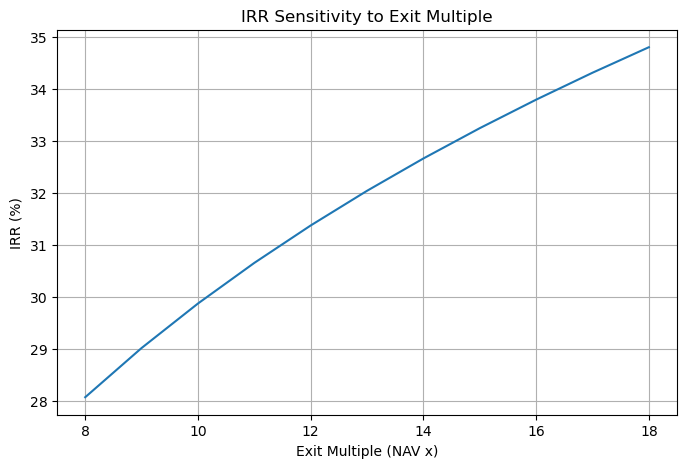

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(sens["Exit_Multiple"], sens["IRR"]*100)
plt.xlabel("Exit Multiple (NAV x)")
plt.ylabel("IRR (%)")
plt.title("IRR Sensitivity to Exit Multiple")
plt.grid(True)
plt.show()


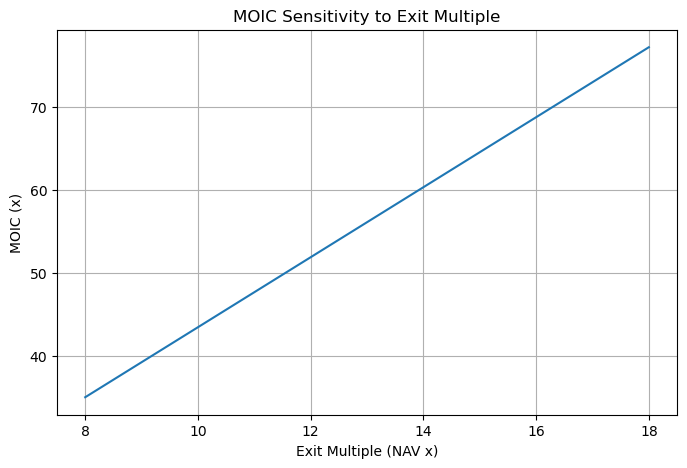

In [11]:
plt.figure(figsize=(8,5))
plt.plot(sens["Exit_Multiple"], sens["MOIC"])
plt.xlabel("Exit Multiple (NAV x)")
plt.ylabel("MOIC (x)")
plt.title("MOIC Sensitivity to Exit Multiple")
plt.grid(True)
plt.show()
